In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)
 
# Random state for reproducibility
RANDOM_STATE = 42
 
print("✅ All libraries loaded successfully!!")

✅ All libraries loaded successfully!!


In [3]:
#Load the ML-ready dataset exported from R
# Contains hub gene expression values + Group label (AD or Control)
df = pd.read_csv("../results/alzheimers_ml_dataset.csv", index_col=0)
 
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["Group"].value_counts())
print("\nMissing Values:", df.isnull().sum().sum())
print("\nFirst 3 Rows:")
df.head(3)

Dataset Shape: (161, 21)

Class Distribution:
Group
AD         100
Control     61
Name: count, dtype: int64

Missing Values: 0

First 3 Rows:


,SNAP25,ACTB,SARS1,ATP5F1B,EGR1,IDH3A,NUTF2,IDH3G,FIG4,SLC17A7,...,ATP6V1E1,MDH2,CDC37,CDK7,NDUFS7,GAPDH,UNC13A,TOMM22,SYT13,Group
GSM119615,2312.7224,4598.3516,482.19553,1391.2039,54.229103,143.91410,203.25010,192.72765,808.54535,3113.4575,...,1060.04660,1492.09300,91.292650,252.44510,151.30120,3329.8200,160.73569,98.396706,125.33188,Control
GSM119616,3648.4580,7851.5107,790.54175,2517.6907,336.944580,130.55396,642.51340,576.21860,1957.63490,7360.9336,...,2256.82230,939.09686,101.329470,253.24144,703.45500,7475.1460,224.34622,9.701952,278.25770,Control
GSM119617,4552.4087,2223.5493,619.89746,1405.9285,406.831970,89.03173,411.27298,325.46613,901.67610,1199.3960,...,392.14584,321.15408,18.731207,70.68781,489.11395,7363.3213,376.78190,55.360138,453.10602,Control


In [4]:
# Separate features (hub gene expression) and labels (AD vs Control)
X = df.drop(columns=["Group"])
y = df["Group"]
 
# Encode labels: Control = 0, AD = 1
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
 
# Scale features using StandardScaler
# Ensures all gene expression values are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
 
# Stratified train/test split (80% train, 20% test)
# Stratified ensures equal class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=RANDOM_STATE
)
 
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Number of features (hub genes): {X_train.shape[1]}")

Label encoding: {'AD': np.int64(0), 'Control': np.int64(1)}

Training samples: 128
Testing samples:  33
Number of features (hub genes): 20


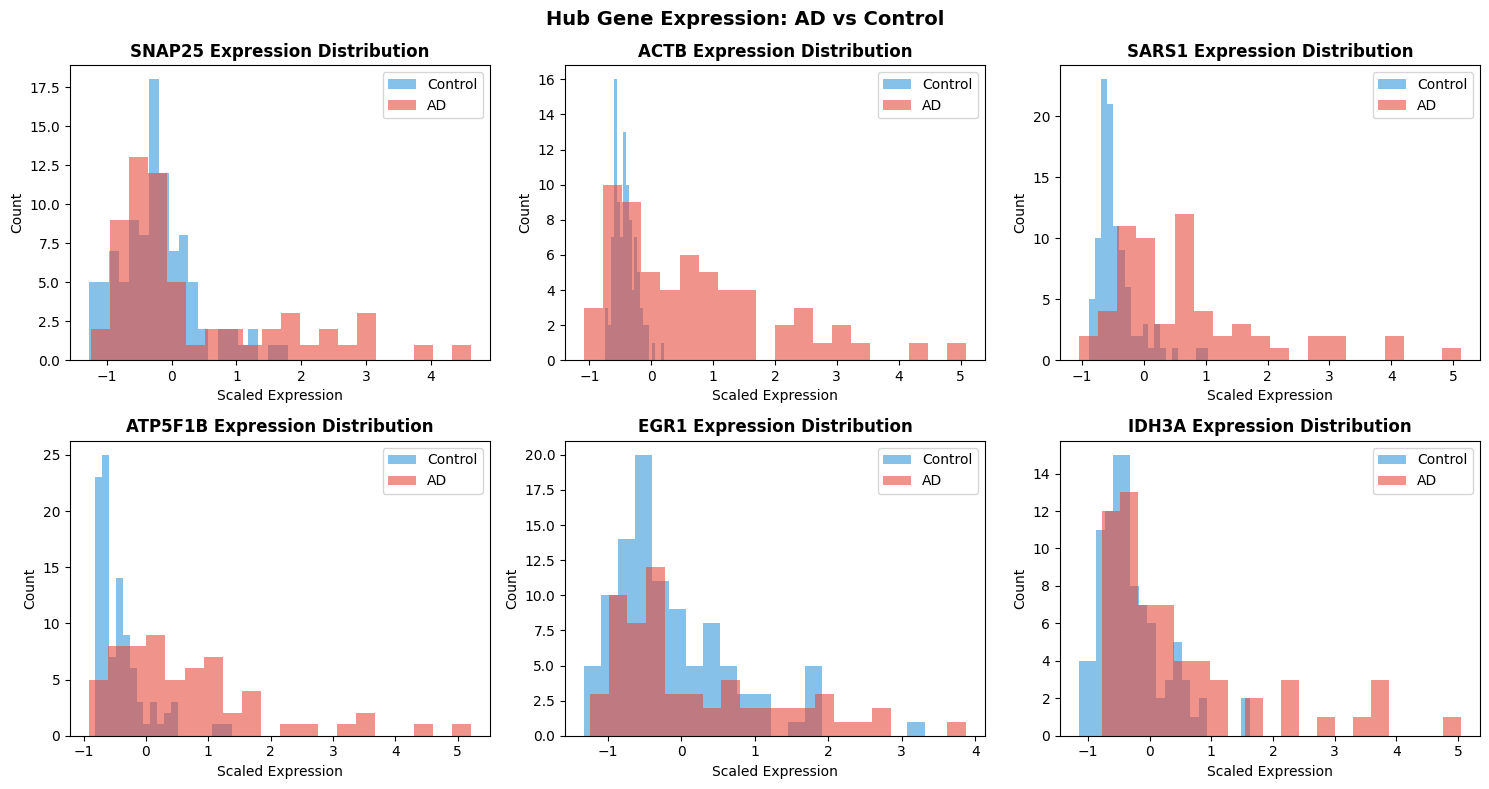

✅ Distribution plot saved!!


In [5]:
# Visualise expression distribution of top 6 hub genes
# Helps understand how well hub genes separate AD from Control
top6_genes = X.columns[:6]
 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
 
for i, gene in enumerate(top6_genes):
    for group, color, label in zip([0, 1], ["#3498DB", "#E74C3C"], ["Control", "AD"]):
        mask = y_enc == group
        axes[i].hist(
            X_scaled.loc[mask.astype(bool), gene],
            bins=20,
            alpha=0.6,
            color=color,
            label=label
        )
    axes[i].set_title(f"{gene} Expression Distribution", fontweight="bold")
    axes[i].set_xlabel("Scaled Expression")
    axes[i].set_ylabel("Count")
    axes[i].legend()
 
plt.suptitle("Hub Gene Expression: AD vs Control", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/hub_gene_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Distribution plot saved!!")

In [6]:
# Train and compare four different classifiers
# Each uses a different approach to learn the AD vs Control boundary
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),
    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    )
}
 
# Cross-validation: 5-fold stratified
# More reliable than single train/test split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
print("=" * 55)
print(f"{'Model':<30} {'CV Accuracy':>12} {'Std Dev':>10}")
print("=" * 55)
 
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y_enc, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:<30} {scores.mean():>11.4f} {scores.std():>10.4f}")
 
print("=" * 55)

Model                           CV Accuracy    Std Dev
Logistic Regression                 0.8886     0.0631
Random Forest                       0.9070     0.0736
Gradient Boosting                   0.8633     0.0581
Support Vector Machine              0.8945     0.0505


In [7]:
# Select the best performing model based on cross-validation accuracy
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model = models[best_model_name]
 
print(f"Best Model: {best_model_name}")
print(f"CV Accuracy: {cv_results[best_model_name].mean():.4f} ± {cv_results[best_model_name].std():.4f}")
 
# Train best model on full training set
best_model.fit(X_train, y_train)
 
# Predict on held-out test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
 
# Final test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Set Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Best Model: Random Forest
CV Accuracy: 0.9070 ± 0.0736

Test Set Accuracy: 0.8788

Classification Report:
              precision    recall  f1-score   support

          AD       0.86      0.95      0.90        20
     Control       0.91      0.77      0.83        13

    accuracy                           0.88        33
   macro avg       0.89      0.86      0.87        33
weighted avg       0.88      0.88      0.88        33



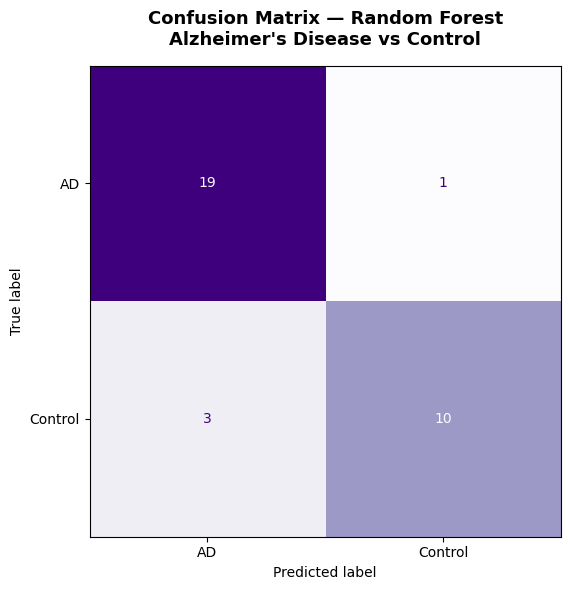

✅ Confusion matrix saved!!


In [8]:
# Confusion matrix shows true vs predicted classifications
# Diagonal = correct predictions | Off-diagonal = errors
fig, ax = plt.subplots(figsize=(7, 6))
 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(
    ax=ax,
    colorbar=False,
    cmap="Purples"
)
 
ax.set_title(
    f"Confusion Matrix — {best_model_name}\nAlzheimer's Disease vs Control",
    fontsize=13,
    fontweight="bold",
    pad=15
)
 
plt.tight_layout()
plt.savefig("../figures/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved!!")

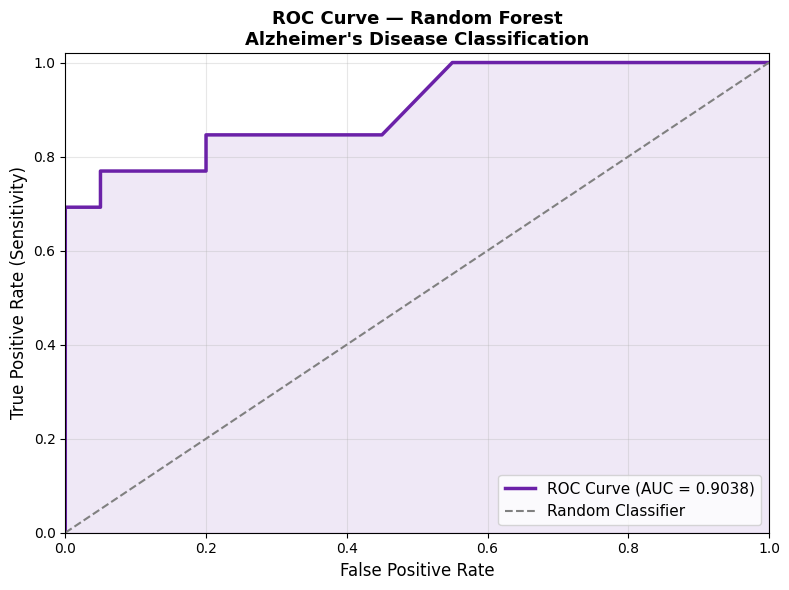

✅ ROC curve saved!! AUC = 0.9038


In [9]:
# ROC curve shows classifier performance across all thresholds
# AUC (Area Under Curve): 1.0 = perfect | 0.5 = random
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
 
fig, ax = plt.subplots(figsize=(8, 6))
 
ax.plot(
    fpr, tpr,
    color="#6B21A8",
    linewidth=2.5,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1.5, label="Random Classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="#6B21A8")
 
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title(
    f"ROC Curve — {best_model_name}\nAlzheimer's Disease Classification",
    fontsize=13,
    fontweight="bold"
)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("../figures/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ ROC curve saved!! AUC = {roc_auc:.4f}")

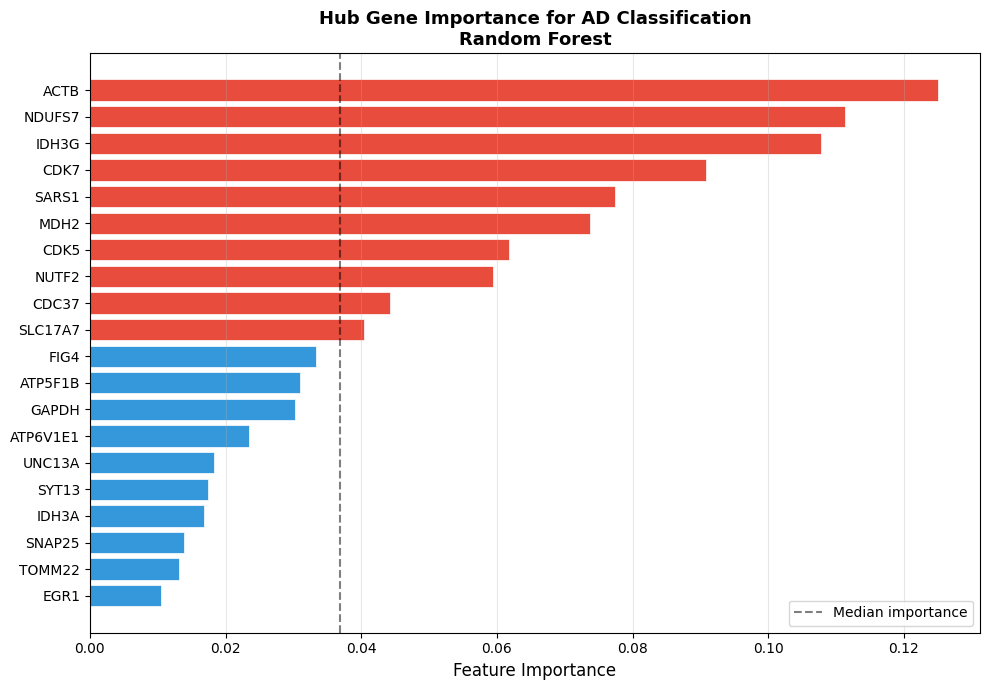

✅ Feature importance plot saved!!
✅ Feature importance CSV saved!!


In [10]:
# Which hub genes are most important for classification??
# Shows which genes contribute most to distinguishing AD from Control
fig, ax = plt.subplots(figsize=(10, 7))
 
if hasattr(best_model, "feature_importances_"):
    # Tree-based models (Random Forest, Gradient Boosting)
    importances = best_model.feature_importances_
    importance_label = "Feature Importance"
elif hasattr(best_model, "coef_"):
    # Linear models (Logistic Regression, SVM)
    importances = np.abs(best_model.coef_[0])
    importance_label = "Absolute Coefficient"
else:
    print("Feature importance not available for this model type!!")
    importances = None
 
if importances is not None:
    feature_importance_df = pd.DataFrame({
        "Gene": X.columns,
        "Importance": importances
    }).sort_values("Importance", ascending=True)
 
    colors = ["#E74C3C" if imp > feature_importance_df["Importance"].median()
              else "#3498DB" for imp in feature_importance_df["Importance"]]
 
    ax.barh(
        feature_importance_df["Gene"],
        feature_importance_df["Importance"],
        color=colors,
        edgecolor="white",
        linewidth=0.5
    )
 
    ax.set_xlabel(importance_label, fontsize=12)
    ax.set_title(
        f"Hub Gene Importance for AD Classification\n{best_model_name}",
        fontsize=13,
        fontweight="bold"
    )
    ax.axvline(
        x=feature_importance_df["Importance"].median(),
        color="black",
        linestyle="--",
        alpha=0.5,
        label="Median importance"
    )
    ax.legend()
    ax.grid(axis="x", alpha=0.3)
 
    plt.tight_layout()
    plt.savefig("../figures/feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✅ Feature importance plot saved!!")
 
    # Save feature importance to CSV
    feature_importance_df.sort_values("Importance", ascending=False).to_csv(
        "../results/feature_importance.csv"
    )
    print("✅ Feature importance CSV saved!!")

C:\Users\Salome\AppData\Local\Temp\ipykernel_12444\3203470167.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=15, ha="right")


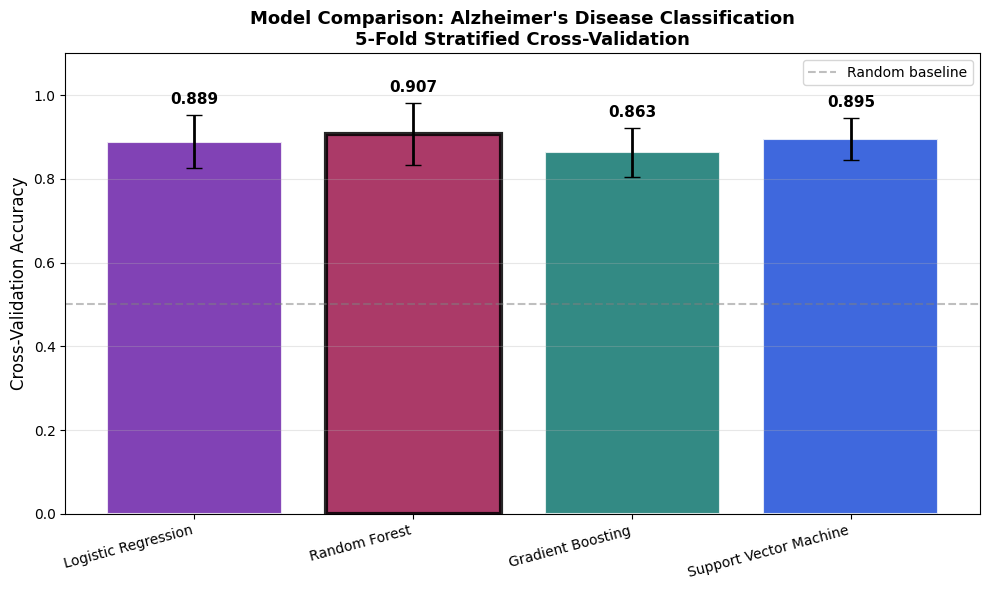

✅ Model comparison plot saved!!


In [12]:
# Visual comparison of all four models by cross-validation accuracy
fig, ax = plt.subplots(figsize=(10, 6))
 
model_names = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names]
stds = [cv_results[m].std() for m in model_names]
colors = ["#6B21A8", "#9D174D", "#0F766E", "#1D4ED8"]
 
bars = ax.bar(
    model_names, means,
    yerr=stds,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
    capsize=6,
    error_kw={"linewidth": 2}
)
# Highlight best model
best_idx = model_names.index(best_model_name)
bars[best_idx].set_edgecolor("black")
bars[best_idx].set_linewidth(3)
 
ax.set_ylabel("Cross-Validation Accuracy", fontsize=12)
ax.set_title(
    "Model Comparison: Alzheimer's Disease Classification\n5-Fold Stratified Cross-Validation",
    fontsize=13,
    fontweight="bold"
)
ax.set_ylim([0, 1.1])
ax.axhline(y=0.5, color="grey", linestyle="--", alpha=0.5, label="Random baseline")
 
for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.02,
        f"{mean:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11
    )
 
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
 
plt.tight_layout()
plt.savefig("../figures/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Model comparison plot saved!!")

In [13]:
# Save a summary of all model performance metrics
summary = pd.DataFrame({
    "Model": model_names,
    "CV_Accuracy_Mean": means,
    "CV_Accuracy_Std": stds
}).sort_values("CV_Accuracy_Mean", ascending=False)
 
summary.to_csv("../results/model_comparison_summary.csv", index=False)
print("✅ Model comparison summary saved!!")
 
# Final summary printout
print("\n" + "=" * 55)
print("ALZHEIMER'S ML CLASSIFIER — COMPLETE!!")
print("=" * 55)
print(f"Best Model:        {best_model_name}")
print(f"Test Accuracy:     {test_accuracy:.4f}")
print(f"ROC AUC Score:     {roc_auc:.4f}")
print(f"Training Samples:  {X_train.shape[0]}")
print(f"Testing Samples:   {X_test.shape[0]}")
print(f"Hub Genes Used:    {X_train.shape[1]}")
print("=" * 55)
print("\nFigures saved to: ../figures/")
print("Results saved to: ../results/")

✅ Model comparison summary saved!!

ALZHEIMER'S ML CLASSIFIER — COMPLETE!!
Best Model:        Random Forest
Test Accuracy:     0.8788
ROC AUC Score:     0.9038
Training Samples:  128
Testing Samples:   33
Hub Genes Used:    20

Figures saved to: ../figures/
Results saved to: ../results/
